In [4]:
from torch.utils.data import Dataset, DataLoader, random_split
import torch
from torch import optim
import torch.nn.functional as tf
from scipy.io import arff
import numpy as np

print(f"cuda available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

cuda available: True
device: cuda


Load data from .arff file.

In [5]:
data = arff.loadarff("../data/msd_rp_msd_top_genres.arff")

First 60 entries of each data instance is the bin values for the rhythm histogram, while the last entry is the label.

In [6]:
features = np.empty((len(data[0]), 1440))
for i, entry in enumerate(data[0]):
    e = list(entry)[:1440]
    features[i] = np.array(e)

In [41]:
features = torch.FloatTensor(features).to(device)

In [7]:
genres_set = set()
for i, entry in enumerate(data[0]):
    genres_set.add(entry[-1])

genres = list(genres_set)
genre_to_idx = {}
for i, g in enumerate(genres):
    genre_to_idx[g] = i

print(genre_to_idx)

{b'Rap': 0, b'Jazz': 1, b'Pop_Rock': 2, b'Electronic': 3, b'Latin': 4, b'RnB': 5, b'Reggae': 6, b'Country': 7, b'Folk': 8, b'Blues': 9, b'Vocal': 10, b'International': 11, b'New Age': 12}


In [8]:
gt_labels = np.empty(len(data[0]))
for i, entry in enumerate(data[0]):
    gt_labels[i] = genre_to_idx[entry[-1]]

print(gt_labels)

[ 2.  2.  2. ... 11.  9.  8.]


Now we have features and ground truth labels ready, split them into train/test sets.

In [42]:
class GenresDataset(Dataset):
    def __init__(self, transform=None, target_transform=None):
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(data[0])

    def __getitem__(self, idx):
        feature = features[idx]
        label = gt_labels[idx]
        if self.transform:
            feature = self.transform(feature)
        if self.target_transform:
            label = self.target_transform(label)
        return feature, label

dataset = GenresDataset()
test_ratio = 0.2
batch_size = 32
test_size = int(len(dataset) * test_ratio)
train_size = len(dataset) - test_size
train_set, test_set = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

Let's visualize the rhythm histogram for several training instances.

In [43]:
sample = enumerate(train_loader)
_, (sample_features, sample_labels) = next(sample)
print(sample_features.shape)

torch.Size([32, 1440])


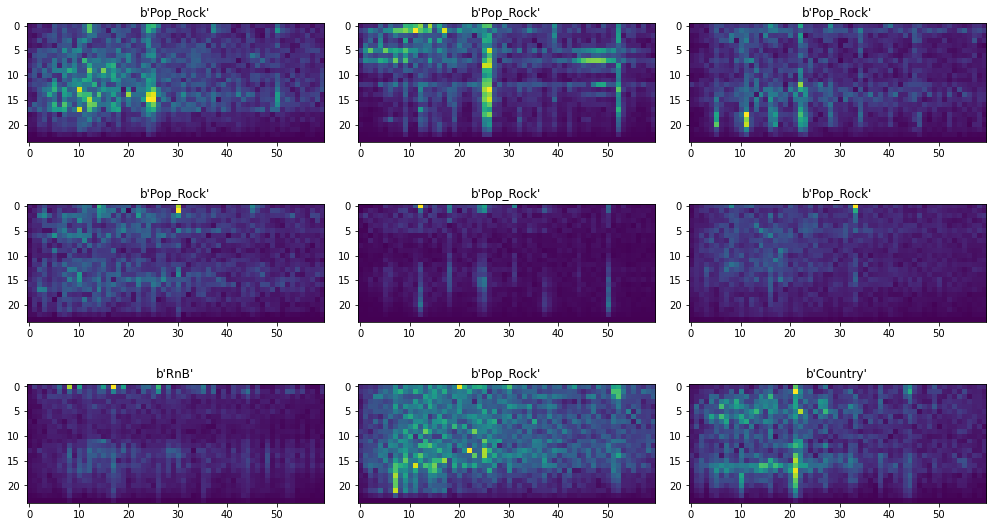

In [45]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(figsize=(14, 8))

for i in range(9):
    plt.subplot(3,3, i + 1)
    plt.tight_layout()
    feat = sample_features[i].to('cpu').view((60, -1)).T
    plt.imshow(feat)
    plt.title(genres[int(sample_labels[i])])

plt.savefig("figures/rp_visualization.png")

Train with a very simple neural network architecture (1 hidden layer of 100 neurons) for proof of concept.

In [92]:
from torch.nn import Linear, Module, Conv2d, Sequential, ReLU, Dropout, MaxPool2d, BatchNorm2d

class RPClassifier(Module):

    def __init__(self, dropout=0.2):
        super(RPClassifier, self).__init__()

        # CONV1 (?, 60, 24, 1)
        # -> (?, 60, 24, 32)
        # -> (?, 30, 12, 32)
        self.conv1 = Sequential(
            Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=1),
            BatchNorm2d(32),
            ReLU(),
            MaxPool2d(kernel_size=2, stride=2),
            Dropout(dropout)
        )

        # Conv2 (?, 30, 12, 32)
        # -> (?, 30, 12, 64)
        # -> (?, 15, 6, 64)
        self.conv2 = Sequential(
            Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=1),
            BatchNorm2d(64),
            ReLU(),
            MaxPool2d(kernel_size=2, stride=2),
            Dropout(dropout)
        )

        # CONV3 (?, 15, 6, 64)
        # -> (?, 15, 6, 128)
        # -> (?, 8, 4, 128)
        self.conv3 = Sequential(
            Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=1),
            BatchNorm2d(128),
            ReLU(),
            MaxPool2d(kernel_size=2, stride=2, padding=1),
            Dropout(dropout)
        )

        # FC1 4096 -> 512
        self.fc1 = Sequential(
            Linear(4096, 512, bias=True),
            ReLU(),
            Dropout(dropout)
        )

        # FC2 1024 -> 13
        self.fc2 = Sequential(
            Linear(512, 13, bias=True),
        )

    def forward(self, x):
        out = self.conv1(x.view(-1, 1, 60, 24))
        out = self.conv2(out)
        out = self.conv3(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

In [97]:
epochs = 15
lr = 0.01
log_interval = 1000
network = RPClassifier()
network.to(device) # Compute on GPU
optimizer = optim.SGD(network.parameters(), lr=lr)

train_losses = []
train_counter = []
test_losses = []
test_counter = [i*len(train_loader.dataset) for i in range(epochs + 1)]

def train(ep):
  network.train()
  for batch_idx, (feature, label) in enumerate(train_loader):
    optimizer.zero_grad()
    output = network(feature)
    loss = tf.cross_entropy(output, label.long().to(device))
    loss.backward()
    optimizer.step()
    if batch_idx % log_interval == 0:
      print('Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
        ep, batch_idx * len(feature), len(train_loader.dataset),
        100. * batch_idx / len(train_loader), loss.item()))
      train_losses.append(loss.item())
      train_counter.append(
        (batch_idx * 64) + ((epoch - 1) * len(train_loader.dataset)))

def test(loader, loader_name):
  network.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for feature, label in loader:
      output = network(feature)
      test_loss += tf.cross_entropy(output, label.long().to(device), size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(label.data.view_as(pred).to(device)).sum()
  test_loss /= len(loader.dataset)
  test_losses.append(test_loss)
  acc = 100. * correct / len(loader.dataset)
  print('\n{}: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
      loader_name, test_loss, correct, len(loader.dataset), acc))
  return test_loss, acc

def test_train_set():
    return test(train_loader, "Train Acc")

def test_test_set():
    return test(test_loader, "Test Acc")

In [118]:
from pytorch_model_summary import summary

print(summary(network, features[0]))

-----------------------------------------------------------------------
      Layer (type)        Output Shape         Param #     Tr. Param #
          Conv2d-1     [1, 32, 60, 24]             320             320
     BatchNorm2d-2     [1, 32, 60, 24]              64              64
            ReLU-3     [1, 32, 60, 24]               0               0
       MaxPool2d-4     [1, 32, 30, 12]               0               0
         Dropout-5     [1, 32, 30, 12]               0               0
          Conv2d-6     [1, 64, 30, 12]          18,496          18,496
     BatchNorm2d-7     [1, 64, 30, 12]             128             128
            ReLU-8     [1, 64, 30, 12]               0               0
       MaxPool2d-9      [1, 64, 15, 6]               0               0
        Dropout-10      [1, 64, 15, 6]               0               0
         Conv2d-11     [1, 128, 15, 6]          73,856          73,856
    BatchNorm2d-12     [1, 128, 15, 6]             256             256
     

In [98]:
losses = []
accuracies = []

loss, acc = test_test_set()

losses.append(loss)
accuracies.append(acc)

for epoch in range(1, epochs + 1):
  train(epoch)
  epoch_loss, epoch_acc = test_test_set()
  losses.append(epoch_loss)
  accuracies.append(epoch_acc)


Test Acc: Avg. loss: 2.5656, Accuracy: 780/80829 (1%)

Epoch: 1 [0/323317 (0%)]	Loss: 2.537858
Epoch: 1 [32000/323317 (10%)]	Loss: 1.226320
Epoch: 1 [64000/323317 (20%)]	Loss: 1.317705
Epoch: 1 [96000/323317 (30%)]	Loss: 1.306759
Epoch: 1 [128000/323317 (40%)]	Loss: 1.235616
Epoch: 1 [160000/323317 (49%)]	Loss: 1.035634
Epoch: 1 [192000/323317 (59%)]	Loss: 1.057214
Epoch: 1 [224000/323317 (69%)]	Loss: 1.227755
Epoch: 1 [256000/323317 (79%)]	Loss: 1.134589
Epoch: 1 [288000/323317 (89%)]	Loss: 0.722067
Epoch: 1 [320000/323317 (99%)]	Loss: 0.767001

Test Acc: Avg. loss: 1.1338, Accuracy: 53537/80829 (66%)

Epoch: 2 [0/323317 (0%)]	Loss: 1.172391
Epoch: 2 [32000/323317 (10%)]	Loss: 0.996494
Epoch: 2 [64000/323317 (20%)]	Loss: 1.148199
Epoch: 2 [96000/323317 (30%)]	Loss: 1.187201
Epoch: 2 [128000/323317 (40%)]	Loss: 1.069236
Epoch: 2 [160000/323317 (49%)]	Loss: 1.013319
Epoch: 2 [192000/323317 (59%)]	Loss: 1.045293
Epoch: 2 [224000/323317 (69%)]	Loss: 1.207923
Epoch: 2 [256000/323317 (79%)

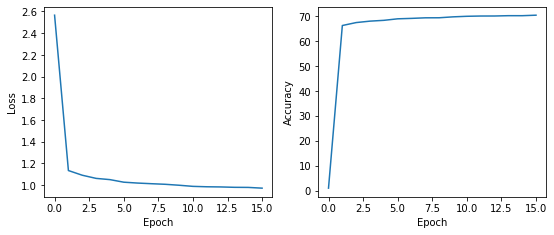

In [121]:
plt.figure(figsize=(9, 3.5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot([acc.cpu() for acc in accuracies])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig("figures/loss_accuracy.png")